# 🎬 Netflix Data Analysis using Python

## Project Overview

This project explores the Netflix Titles dataset using Python. The objective is to clean the data, perform exploratory data analysis (EDA), create meaningful visualizations, and derive business insights.

### Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

### Dataset
Netflix Movies and TV Shows Dataset

# 📚 Import Required Libraries

In this section, we import all the necessary Python libraries required for data manipulation, visualization, and analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10,6)

# 📂 Load the Dataset

The Netflix dataset is loaded into a Pandas DataFrame for further analysis.

In [2]:
df = pd.read_csv("netflix_titles.csv")

# 🔍 Initial Data Exploration

Before cleaning the data, let's understand the dataset by checking:

- Number of rows and columns
- Column names
- Data types
- Sample records
- Dataset information

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [5]:
df.shape

(8807, 12)

In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# 🧹 Data Cleaning

Data cleaning improves the quality of the dataset by:

- Removing duplicate records
- Handling missing values
- Correcting data types
- Creating new useful features

df.isnull().sum()

In [9]:
(df.isnull().sum()/len(df))*100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

## Removing Duplicate Records

Duplicate records may affect analysis results. Here we identify and remove duplicate entries.

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

Handling Missing Values
This section identifies missing values in the dataset and fills or removes them appropriately to ensure accurate analysis.

In [12]:
df["director"] = df["director"].fillna("Unknown")

df["cast"] = df["cast"].fillna("Unknown")

df["country"] = df["country"].fillna("Unknown")

df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

df["date_added"] = df["date_added"].fillna("Not Available")

In [13]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64

# ⚙️ Feature Engineering

New features are created from existing columns to make analysis easier.

Examples include:

- Added Year
- Added Month
- Movie Duration
- Number of Seasons

In [14]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [15]:
df["Added_Year"] = df["date_added"].dt.year

In [16]:
df["Added_Month"] = df["date_added"].dt.month_name()

In [17]:
df.describe()

,date_added,release_year,Added_Year
count,8709,8807.000000,8709.000000
mean,2019-05-23 01:45:29.452290816,2014.180198,2018.887932
min,2008-01-01 00:00:00,1925.000000,2008.000000
25%,2018-04-20 00:00:00,2013.000000,2018.000000
50%,2019-07-12 00:00:00,2017.000000,2019.000000
75%,2020-08-26 00:00:00,2019.000000,2020.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000
std,NaN,8.819312,1.567961


In [18]:
df.describe(include="object")

,show_id,type,title,director,cast,country,rating,duration,listed_in,description,Added_Month
count,8807,8807,8807,8807,8807,8807,8807,8804,8807,8807,8709
unique,8807,2,8804,4529,7693,749,17,220,514,8775,12
top,s1,Movie,15-Aug,Unknown,Unknown,United States,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope...",July
freq,1,6131,2,2634,825,2818,3211,1793,362,4,819


# 📊 Exploratory Data Analysis (EDA)

EDA helps understand patterns, trends, and relationships within the dataset using statistical summaries and visualizations.

In [19]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

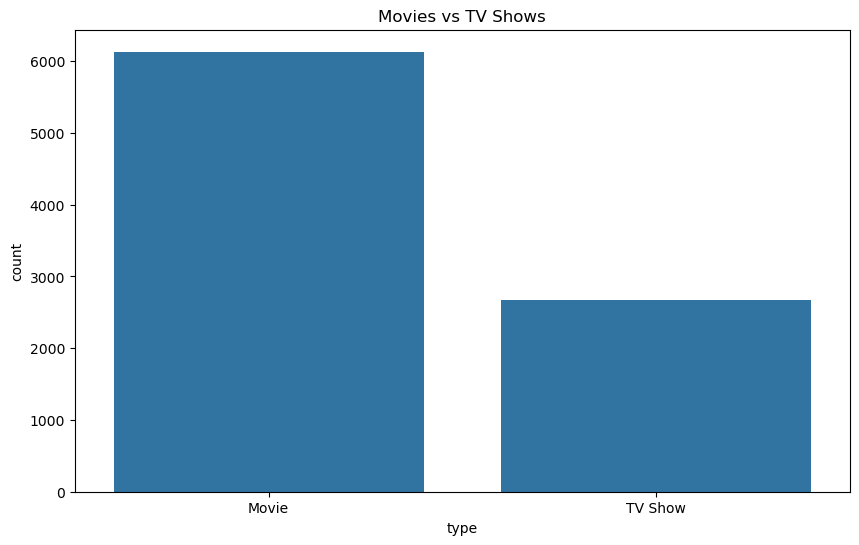

In [20]:
sns.countplot(data=df,x="type")
plt.title("Movies vs TV Shows")
plt.show()

In [22]:
top_country = df["country"].value_counts().head(10)

top_country

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

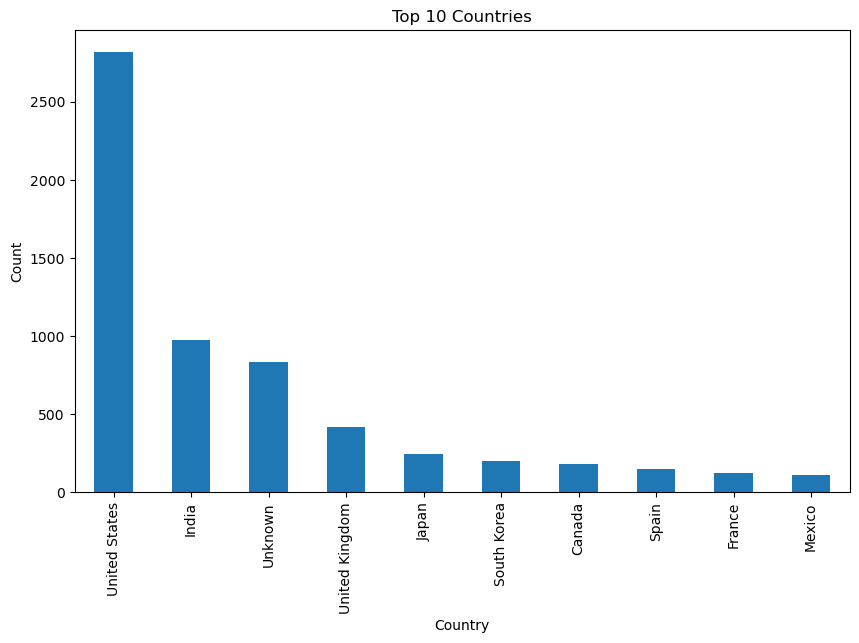

In [23]:
top_country.plot(kind="bar")

plt.title("Top 10 Countries")

plt.xlabel("Country")

plt.ylabel("Count")

plt.show()

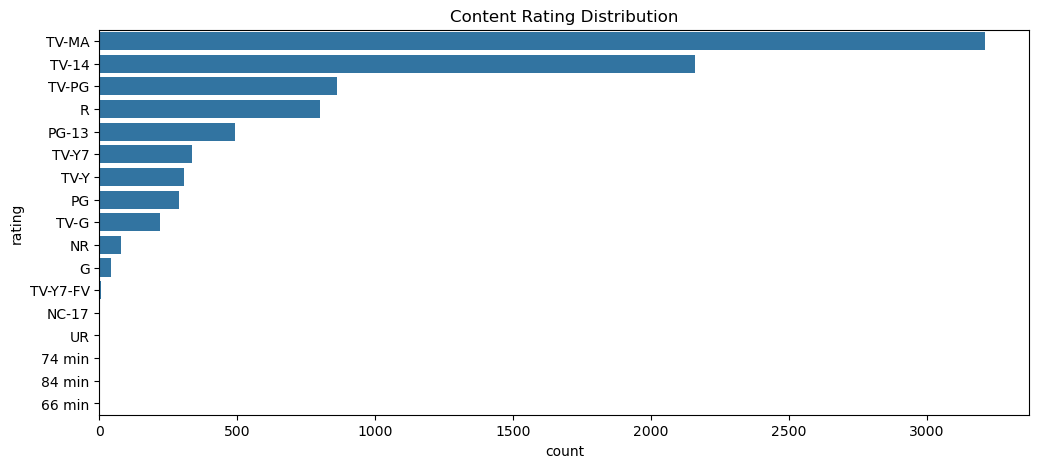

In [24]:
plt.figure(figsize=(12,5))

sns.countplot(data=df,y="rating",
order=df["rating"].value_counts().index)

plt.title("Content Rating Distribution")

plt.show()

In [25]:
genre = df["listed_in"].str.split(", ").explode()

genre.value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

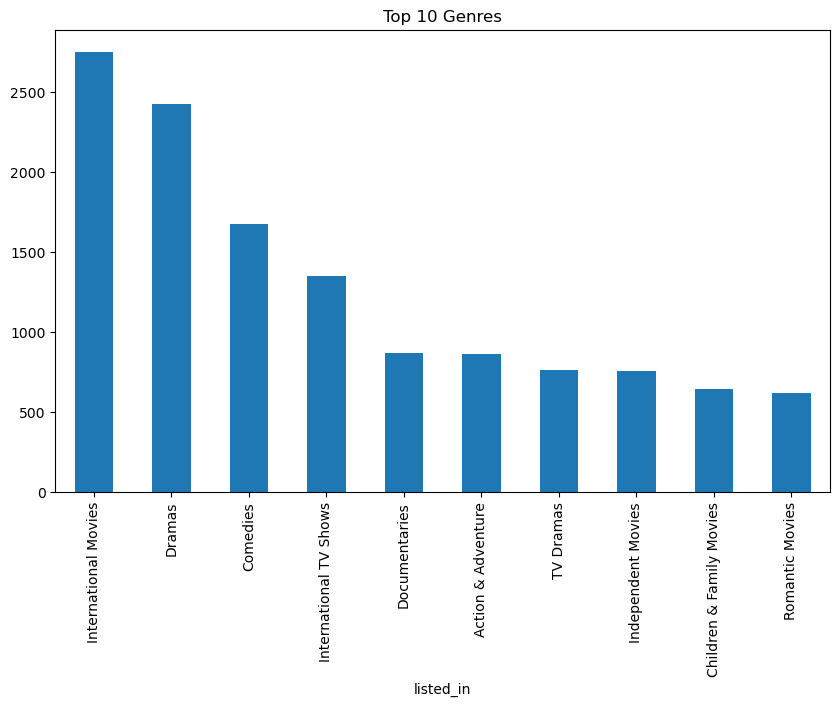

In [26]:
genre.value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Genres")

plt.show()

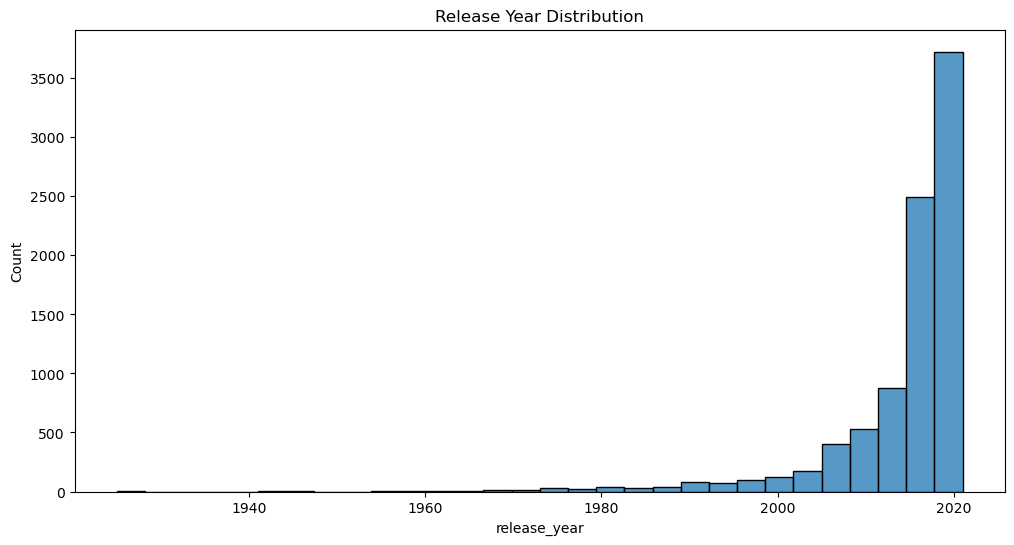

In [27]:
plt.figure(figsize=(12,6))

sns.histplot(df["release_year"], bins=30)

plt.title("Release Year Distribution")

plt.show()

In [28]:
df["Added_Year"].value_counts().sort_index()

Added_Year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

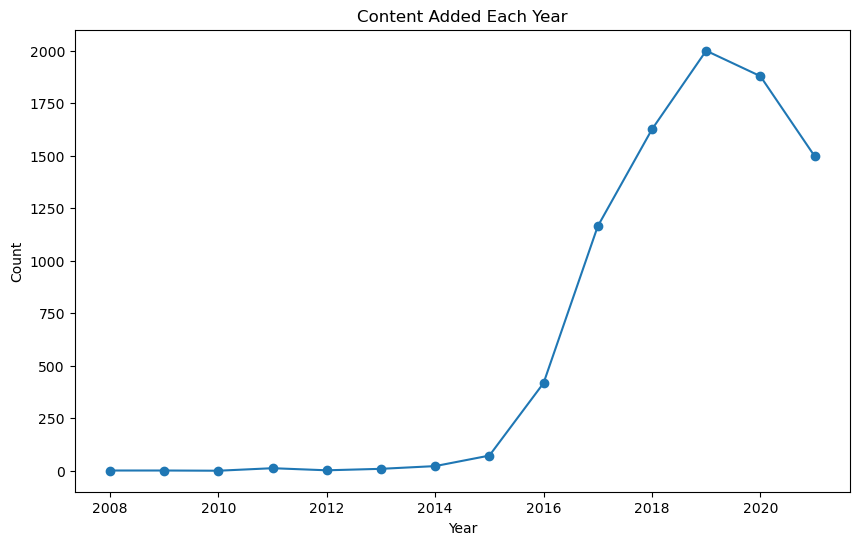

In [29]:
df["Added_Year"].value_counts().sort_index().plot(marker="o")

plt.title("Content Added Each Year")

plt.xlabel("Year")

plt.ylabel("Count")

plt.show()


In [30]:
top_director = df[df["director"]!="Unknown"]["director"].value_counts().head(10)

top_director

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

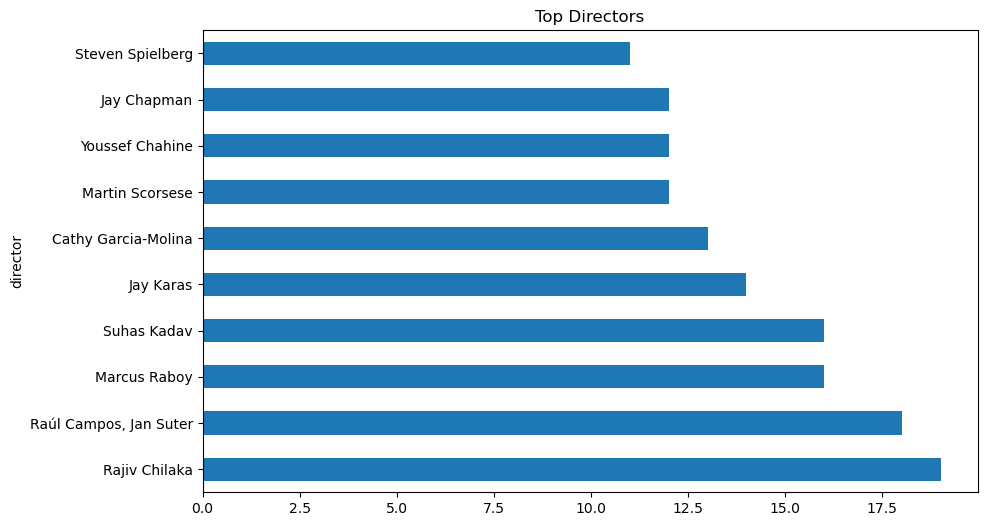

In [31]:
top_director.plot(kind="barh")

plt.title("Top Directors")

plt.show()

In [32]:
movies = df[df["type"]=="Movie"].copy()

movies["duration"] = movies["duration"].str.replace(" min","")

movies["duration"] = pd.to_numeric(movies["duration"])

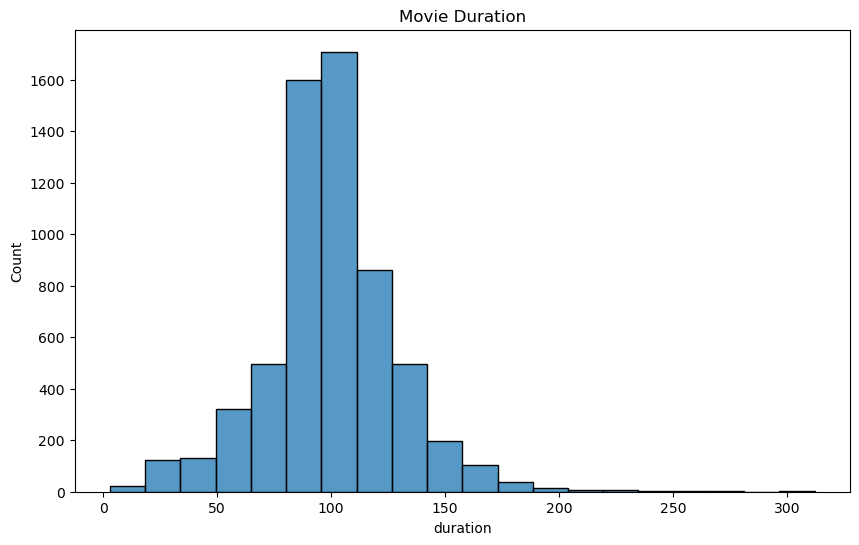

In [33]:
sns.histplot(movies["duration"],bins=20)

plt.title("Movie Duration")

plt.show()

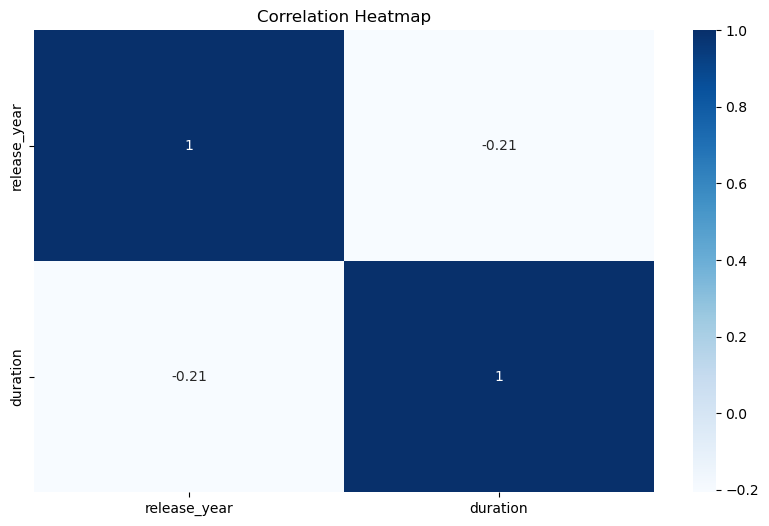

In [34]:
numeric = movies[["release_year","duration"]]

sns.heatmap(numeric.corr(),
annot=True,
cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

# 🔥 Correlation Analysis

A correlation heatmap is used to understand relationships between numerical variables in the dataset.

In [35]:
print("Total Titles:",len(df))

print("Movies:",len(df[df["type"]=="Movie"]))

print("TV Shows:",len(df[df["type"]=="TV Show"]))

print("Latest Release Year:",df["release_year"].max())

print("Oldest Release Year:",df["release_year"].min())

Total Titles: 8807
Movies: 6131
TV Shows: 2676
Latest Release Year: 2021
Oldest Release Year: 1925


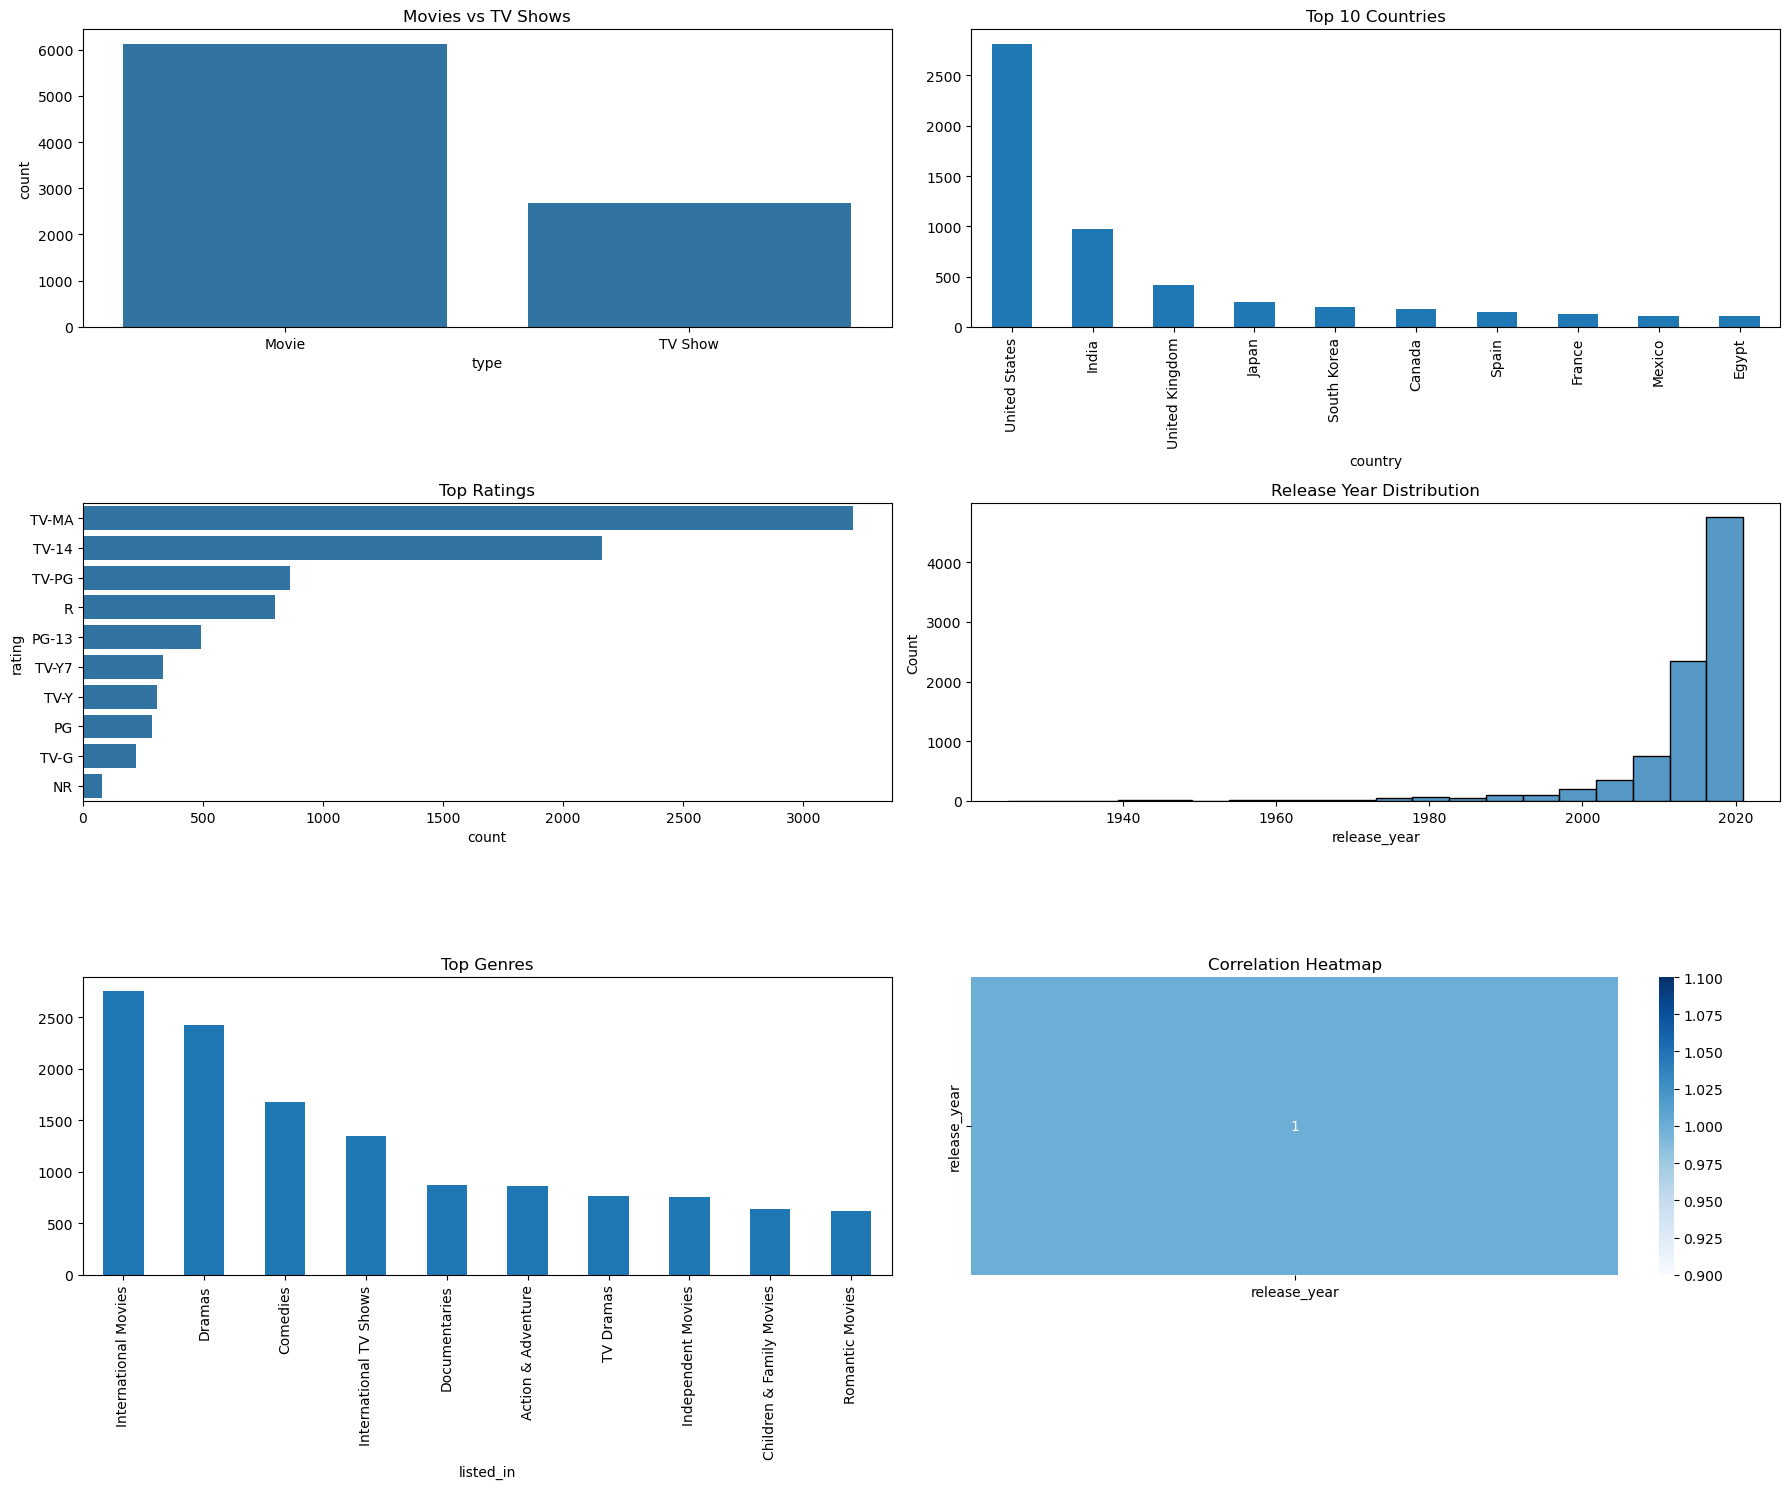

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 2, figsize=(18, 15))

# 1. Movies vs TV Shows
sns.countplot(data=df, x='type', ax=axes[0,0])
axes[0,0].set_title("Movies vs TV Shows")

# 2. Top 10 Countries
top_country = df['country'].value_counts().head(10)
top_country.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title("Top 10 Countries")

# 3. Ratings
sns.countplot(data=df, y='rating',
              order=df['rating'].value_counts().index[:10],
              ax=axes[1,0])
axes[1,0].set_title("Top Ratings")

# 4. Release Year
sns.histplot(df['release_year'], bins=20, ax=axes[1,1])
axes[1,1].set_title("Release Year Distribution")

# 5. Top Genres
genres = df['listed_in'].str.split(', ').explode()
genres.value_counts().head(10).plot(kind='bar', ax=axes[2,0])
axes[2,0].set_title("Top Genres")

# 6. Correlation Heatmap
numeric = df.select_dtypes(include='number')
sns.heatmap(numeric.corr(), annot=True, cmap='Blues', ax=axes[2,1])
axes[2,1].set_title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("Dashboard_Visuals.png", dpi=300, bbox_inches="tight")

plt.show()

In [36]:
df.to_csv("Netflix_Cleaned.csv",index=False)


# 💡 Business Insights

Based on the exploratory analysis, the following insights can be derived:

- Movies dominate the Netflix library.
- The United States contributes the highest number of titles.
- TV-MA is the most common content rating.
- International Movies is one of the most popular genres.
- Netflix significantly expanded its content library after 2016.

# ✅ Conclusion

This project demonstrated how Python can be used to clean, analyze, and visualize real-world datasets.

### Key Takeaways

- Successfully cleaned the Netflix dataset.
- Performed comprehensive exploratory data analysis.
- Created informative visualizations.
- Derived meaningful business insights.

### Future Scope

- Build a recommendation system.
- Perform sentiment analysis on user reviews.
- Develop an interactive Power BI dashboard.
- Create a Streamlit web application for visualization.

# 🙌 Thank You

Thank you for exploring this project.

If you found this project useful, feel free to ⭐ star the repository on GitHub.

## Connect with Me

**Name:** Vrushti Desai

**Role:** B.Sc. Data Science Student | Aspiring Data Analyst

### Skills

- Python
- SQL
- Power BI
- Excel
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Data Visualization
- Machine Learning (Beginner)